# NDPointIndex

This uses one of the new indexes xarray is providing. See [xarray-indexes](https://xarray-indexes.readthedocs.io/) for more in-depth details on that.

Needs latest xarray '2025.7.1'

In [1]:
import cmweather  # noqa
import numpy as np
import xarray as xr
from open_radar_data import DATASETS

In [2]:
xr.__version__

'2025.7.1'

# Step-by-step guide

## Load radar data

In [3]:
fname = DATASETS.fetch("DWD-Vol-2_99999_20180601054047_00.h5")
ds = xr.open_dataset(fname, engine="gamic", group="sweep_9")
display(ds)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.Dataset> Size: 17MB
Dimensions:            (azimuth: 360, range: 1000)
Coordinates:
  * azimuth            (azimuth) float64 3kB 0.5109 1.519 2.519 ... 358.5 359.5
    elevation          (azimuth) float64 3kB ...
    time               (azimuth) datetime64[ns] 3kB ...
  * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
Data variables: (12/18)
    DBZH               (azimuth, range) float32 1MB ...
    DBZV               (azimuth, range) float32 1MB ...
    KDP                (azimuth, range) float32 1MB ...
    RHOHV              (azimuth, range) float32 1MB ...
    DBTH               (azimuth, range) float32 1MB ...
    DBTV               (azimuth, range) float32 1MB ...
    ...                 ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
    nyquist_velocity   float64 8B ...
Attributes:
    source:         gamic
    ant_gain_h:     43
    ant_gain_v:     43
    noise_power_h:  -3.40133
    noise_power_v:  -3.13518
    rx_loss_h:      3
    rx_loss_v:      3

## Georeference

Add x,y,z - 2D-coordinates.

In [4]:
ds = ds.xradar.georeference()
display(ds)

<xarray.Dataset> Size: 26MB
Dimensions:            (azimuth: 360, range: 1000)
Coordinates:
  * azimuth            (azimuth) float64 3kB 0.5109 1.519 2.519 ... 358.5 359.5
    elevation          (azimuth) float64 3kB 0.5988 0.5988 ... 0.5988 0.5988
    time               (azimuth) datetime64[ns] 3kB ...
  * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
    longitude          float64 8B 6.457
    latitude           float64 8B 50.93
    altitude           float64 8B 310.0
    crs_wkt            int64 8B 0
    x                  (azimuth, range) float64 3MB 0.6686 2.006 ... -1.293e+03
    y                  (azimuth, range) float64 3MB 74.99 225.0 ... 1.499e+05
    z                  (azimuth, range) float64 3MB 310.8 312.4 ... 3.2e+03
Data variables: (12/18)
    DBZH               (azimuth, range) float32 1MB ...
    DBZV               (azimuth, range) float32 1MB ...
    KDP                (azimuth, range) float32 1MB ...
    RHOHV              (azimuth, range) float32 1MB ...
    DBTH               (azimuth, range) float32 1MB ...
    DBTV               (azimuth, range) float32 1MB ...
    ...                 ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
    nyquist_velocity   float64 8B ...
Attributes:
    source:         gamic
    ant_gain_h:     43
    ant_gain_v:     43
    noise_power_h:  -3.40133
    noise_power_v:  -3.13518
    rx_loss_h:      3
    rx_loss_v:      3

## Add NDPointIndex

This uses scipy.KDTree under the hood. See also Indexes-Section in the html-repr below.

In [5]:
ds = ds.set_xindex(("x", "y"), xr.indexes.NDPointIndex)
display(ds)

<xarray.Dataset> Size: 26MB
Dimensions:            (azimuth: 360, range: 1000)
Coordinates:
  * azimuth            (azimuth) float64 3kB 0.5109 1.519 2.519 ... 358.5 359.5
    elevation          (azimuth) float64 3kB 0.5988 0.5988 ... 0.5988 0.5988
    time               (azimuth) datetime64[ns] 3kB ...
  * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
    longitude          float64 8B 6.457
    latitude           float64 8B 50.93
    altitude           float64 8B 310.0
    crs_wkt            int64 8B 0
    z                  (azimuth, range) float64 3MB 310.8 312.4 ... 3.2e+03
  * x                  (azimuth, range) float64 3MB 0.6686 2.006 ... -1.293e+03
  * y                  (azimuth, range) float64 3MB 74.99 225.0 ... 1.499e+05
Data variables: (12/18)
    DBZH               (azimuth, range) float32 1MB ...
    DBZV               (azimuth, range) float32 1MB ...
    KDP                (azimuth, range) float32 1MB ...
    RHOHV              (azimuth, range) float32 1MB ...
    DBTH               (azimuth, range) float32 1MB ...
    DBTV               (azimuth, range) float32 1MB ...
    ...                 ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
    nyquist_velocity   float64 8B ...
Indexes:
  ┌ x        NDPointIndex (ScipyKDTreeAdapter)
  └ y
Attributes:
    source:         gamic
    ant_gain_h:     43
    ant_gain_v:     43
    noise_power_h:  -3.40133
    noise_power_v:  -3.13518
    rx_loss_h:      3
    rx_loss_v:      3

## Plot

This works as usual with the new NDPointIndex.

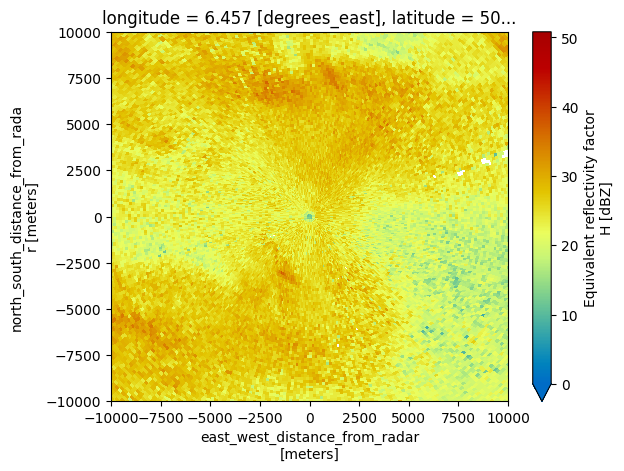

In [6]:
ds.DBZH.plot(
    x="x", y="y", xlim=(-10e3, 10e3), ylim=(-10e3, 10e3), cmap="HomeyerRainbow", vmin=0
)

## Nearest neighbour interpolation with NDPointIndex


### Create 1D DataArrays for x and y selection

In [7]:
y = xr.DataArray(np.arange(-100e3, 100e3, 500), dims="y", name="y", attrs=ds.y.attrs)
x = xr.DataArray(np.arange(-100e3, 100e3, 500), dims="x", name="x", attrs=ds.x.attrs)

### Select with above 1D DataArrays

In [8]:
actual = ds.sel(y=y, x=x, method="nearest")

### Assign the 1D DataArrays

In [9]:
actual = actual.assign(x=x, y=y)

In [10]:
display(actual)

<xarray.Dataset> Size: 13MB
Dimensions:            (y: 400, x: 400)
Coordinates:
    azimuth            (y, x) float64 1MB 224.5 224.5 224.5 ... 44.51 44.51
    elevation          (y, x) float64 1MB 0.5988 0.5988 0.5988 ... 0.5988 0.5988
    time               (y, x) datetime64[ns] 1MB ...
    range              (y, x) float32 640kB 1.415e+05 1.411e+05 ... 1.408e+05
    longitude          float64 8B 6.457
    latitude           float64 8B 50.93
    altitude           float64 8B 310.0
    crs_wkt            int64 8B 0
    z                  (y, x) float64 1MB 2.968e+03 2.956e+03 ... 2.948e+03
  * x                  (x) float64 3kB -1e+05 -9.95e+04 ... 9.9e+04 9.95e+04
  * y                  (y) float64 3kB -1e+05 -9.95e+04 ... 9.9e+04 9.95e+04
Data variables: (12/18)
    DBZH               (y, x) float32 640kB ...
    DBZV               (y, x) float32 640kB ...
    KDP                (y, x) float32 640kB ...
    RHOHV              (y, x) float32 640kB ...
    DBTH               (y, x) float32 640kB ...
    DBTV               (y, x) float32 640kB ...
    ...                 ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
    nyquist_velocity   float64 8B ...
Attributes:
    source:         gamic
    ant_gain_h:     43
    ant_gain_v:     43
    noise_power_h:  -3.40133
    noise_power_v:  -3.13518
    rx_loss_h:      3
    rx_loss_v:      3

## Plot cartesian representation

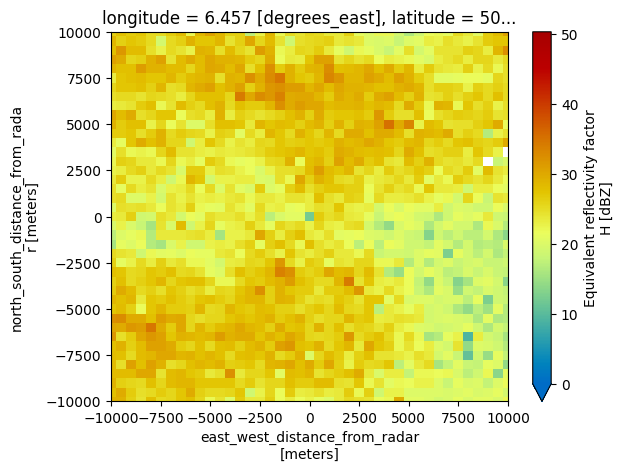

In [11]:
actual.DBZH.plot(xlim=(-10e3, 10e3), ylim=(-10e3, 10e3), cmap="HomeyerRainbow", vmin=0)